# Lab 2: Kernel density estimation

## Introduction to Statistical Estimation, Centrale Lille

So far in this course we have studied so-called parametric estimation methods: we fix a parametric family of distributions to which the data-generating distribution is assumed to belong, then estimate its parameters from the data (for example by maximum likelihood).

In this lab we introduce a **non-parametric** method for estimating the density function, called kernel density estimation. We no longer make any assumption on the data-generating distribution, and instead directly estimate the density $f$ of the parent distribution (assumed continuous). The method therefore applies only to continuous random variables.

**Report by Ugo Roccamatisi.**


In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats as ss

### Part 1 - Histograms

Let $(x_1, ..., x_n)$ be $n$ independent realizations of a real random variable.

Let $x_0 \in \mathbb{R}$ and $h > 0$. The real line is partitioned into intervals of equal length $h$, called *bins*:
$$\forall k \in \mathbb{Z},~B_k =~]x_0 + (k-1)h~;~x_0 + kh].$$

The histogram is the piecewise-constant function defined by:
$$\forall x \in B_k,~H_n(x) = n_k,$$
where $n_k$ is the number of realizations falling in bin $B_k$.

**Q1**. How should $H_n$ be normalized to obtain an estimator of the density function? Recall that $\int_{\mathbb{R}} f(x) dx = 1$.

In what follows, $\hat{f}_n$ denotes this estimator of $f$.

**Answer.** Each bin of width $h$ has area $n_k h$ in the raw histogram. Since $\sum_k n_k=n$, the estimated density is $\hat f_n(x)=n_k/(nh)$ for $x\in B_k$, so that $\int \hat f_n(x)\,dx=1$.


**Q2 (bonus).** For all $x \in \mathbb{R}$, compute the bias and the variance of $\hat{f}_n(x)$. Comment.

**Answer (bonus).** For a fixed $x$ in bin $B_k$, let $p_k=P(X\in B_k)=\int_{B_k}f(u)\,du$. Since $n_k\sim\mathrm{Binom}(n,p_k)$, $E[\hat f_n(x)]=p_k/h$, hence the **exact** bias $p_k/h-f(x)$ and the **exact** variance $p_k(1-p_k)/(nh^2)$. As $h\to0$, the expectation tends to $f(x)$ at continuity points, while the variance is of order $1/(nh)$. We therefore need both $h\to0$ and $nh\to\infty$.

**Q3**. Set $x_0 = \min_i x_i$. The value of $h$ can be set indirectly through the number of bins $N_b$ between $\min_i x_i$ and $\max_i x_i$, so that
$$h = \frac{\max_i x_i - \min_i x_i}{N_b}.$$

Generate 200 points from a 1D two-component Gaussian mixture with $\mu_1 = -2.5, \mu_2 = 1.5, \sigma_1 = \sigma_2 = 1, \pi_1 = 0.4, \pi_2 = 0.6$.

Show the influence of $h$ on the normalized histogram (use the values of Nb suggested in the code cell).

Use `np.histogram` to compute the $n_k$ and `plt.bar` to plot $\hat{f}_n$. Overlay the theoretical density of the Gaussian mixture. Comment.

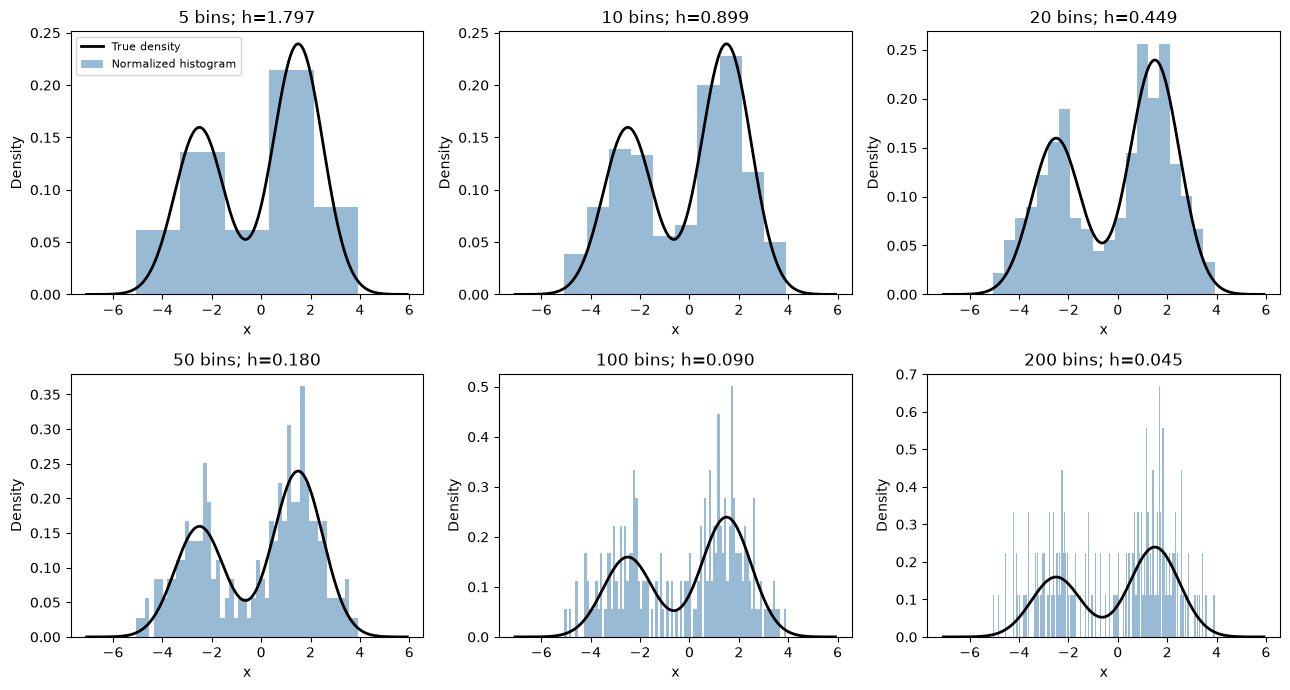

In [2]:
# Reproducible draw: the first component has probability 0.4.
rng=np.random.default_rng(42)
N=200;Nb_list=[5,10,20,50,100,200]
labels=rng.random(N)<.4
sample=np.where(labels,rng.normal(-2.5,1,N),rng.normal(1.5,1,N))
xgrid=np.linspace(sample.min()-2,sample.max()+2,500)
true_density=.4*ss.norm.pdf(xgrid,-2.5,1)+.6*ss.norm.pdf(xgrid,1.5,1)
fig,axes=plt.subplots(2,3,figsize=(13,7))
for ax,nb in zip(axes.flat,Nb_list):
    counts,edges=np.histogram(sample,bins=nb,range=(sample.min(),sample.max()))
    h=np.diff(edges)[0]
    ax.bar(edges[:-1],counts/(N*h),width=h,align='edge',color='steelblue',alpha=.55,label='Normalized histogram')
    ax.plot(xgrid,true_density,'k',lw=2,label='True density')
    ax.set(title=f'{nb} bins; h={h:.3f}',xlabel='x',ylabel='Density')
axes.flat[0].legend(fontsize=8);fig.tight_layout();plt.show()

**Answer.** With few bins, the two modes can merge and the curve is oversmoothed. With too many bins, the counts per bin are small and the estimate becomes very irregular. The intermediate number of bins shows the two bumps best.

**Q4**. What are the main limitations of the histogram as an estimator of the density function?

**Answer.** The histogram is discontinuous and depends on the choice of bin width and bin origin; its value can change when the bin edges are shifted slightly. In several dimensions, the number of cells explodes and most of them are nearly empty.

### Part 2 - Kernel density estimation in 1D

$(x_1, ..., x_n)$ are still $n$ independent realizations of a real random variable.

One of the main motivations is to make the estimate depend directly on the data rather than on an arbitrary partition of $\mathbb{R}$. To do so, we use the following methodology:
- Choose a function $K$ called the "kernel", non-negative, symmetric, and integrating to 1.
- Center $K$ on each observation $x_i$.
- The kernel estimator is then
$$\hat{f}_n(x) = \frac{1}{n} \sum_{i=1}^n K(x - x_i).$$

For example, choosing continuous and everywhere differentiable kernels $K$ gives $\hat{f}_n$ the same properties.

**Q1**. We first use a Gaussian kernel:
$$K(x) = \frac{1}{\sqrt{2 \pi}} \exp \left( -\frac{x^2}{2} \right).$$

Take 10 observations from the data generated in Part 1. On a single plot, show the 10 kernels (normalized by $n$) centered on the observations, and the kernel estimator $\hat{f}_n$. Overlay the true density $f$. Comment.

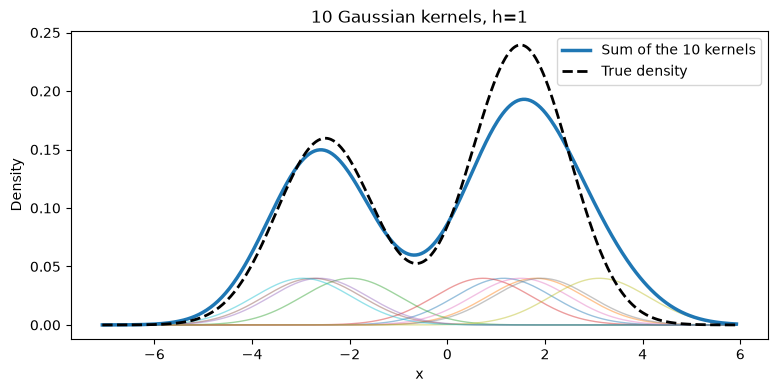

Estimated numerical integral: 0.9997424464211063


In [3]:
# Ten distinct observations; here h=1, i.e. the kernel of the question.
ten=sample[rng.choice(N,size=10,replace=False)]
kernels=ss.norm.pdf(xgrid[:,None],loc=ten[None,:],scale=1)/10
estimated=kernels.sum(axis=1)
fig,ax=plt.subplots(figsize=(9,4))
for i in range(10):ax.plot(xgrid,kernels[:,i],alpha=.45,lw=1)
ax.plot(xgrid,estimated,label='Sum of the 10 kernels',lw=2.5)
ax.plot(xgrid,true_density,'k--',label='True density',lw=2)
ax.set(xlabel='x',ylabel='Density',title='10 Gaussian kernels, h=1');ax.legend();plt.show()
print('Estimated numerical integral:',np.trapezoid(estimated,xgrid))

**Answer.** Each point contributes a small density centered on it; their sum (10 kernels, each divided by 10) is a smooth density integrating to 1. With only 10 observations, it follows the theoretical density less closely than the estimate built from 200 points.

**Q2**. In practice, the estimator depends on a smoothing parameter $h > 0$, called the bandwidth.

The (actual) kernel estimator, also called the Parzen-Rosenblatt method after the two statisticians who developed it, is:
$$\hat{f}_n(x) = \frac{1}{nh} \sum_{i=1}^n K(\frac{x - x_i}{h}).$$

(One can easily check that $\hat{f}_n(x)$ integrates to 1.)

Implement this estimator on the data generated in Part 1 and show the influence of $h$. Comment.

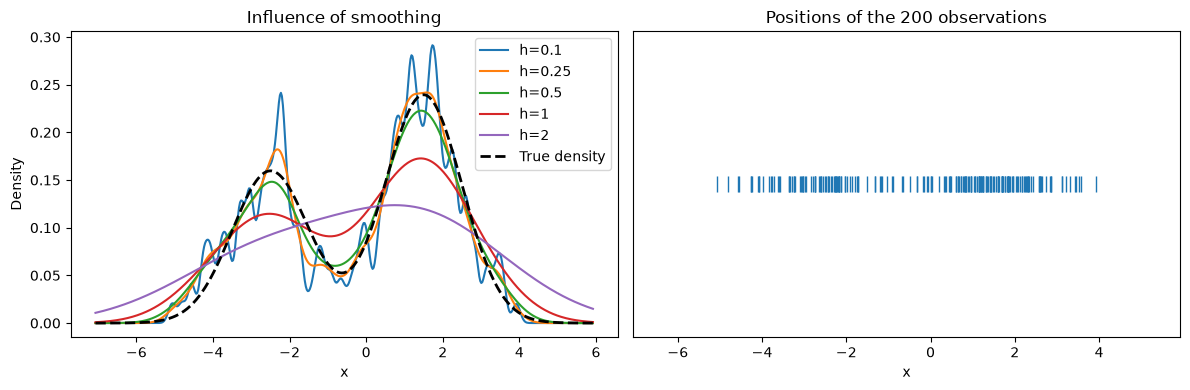

In [4]:
def gaussian_kde_1d(grid,sample,h):
    # N(x_i,h²), integrates to 1; averaged over all observed points.
    return ss.norm.pdf((grid[:,None]-sample[None,:])/h).mean(axis=1)/h
bandwidths=[.1,.25,.5,1,2]
fig,axes=plt.subplots(1,2,figsize=(12,4))
for h in bandwidths:axes[0].plot(xgrid,gaussian_kde_1d(xgrid,sample,h),label=f'h={h}')
axes[0].plot(xgrid,true_density,'k--',lw=2,label='True density');axes[0].legend()
axes[0].set(xlabel='x',ylabel='Density',title='Influence of smoothing')
axes[1].plot(sample,np.zeros_like(sample),'|',ms=12)
axes[1].set(xlim=(xgrid.min(),xgrid.max()),yticks=[],xlabel='x',title='Positions of the 200 observations')
fig.tight_layout();plt.show()

**Answer.** A small h gives peaks close to the observations: low local bias but high variability. A large h smooths out fluctuations but may merge the two modes: higher bias. The black curve is the true density, available here only because the data are simulated.

**Q3.** We now look at other kernels. This time the estimator is not implemented by hand; we use `scikit-learn`, which provides six different kernels (including the Gaussian kernel) in `sklearn.neighbors.KernelDensity` (see the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KernelDensity.html)).

Plot the six kernels. Comment.

For a fixed bandwidth (for example $h = 0.5$), show the influence of the different kernels. Comment.

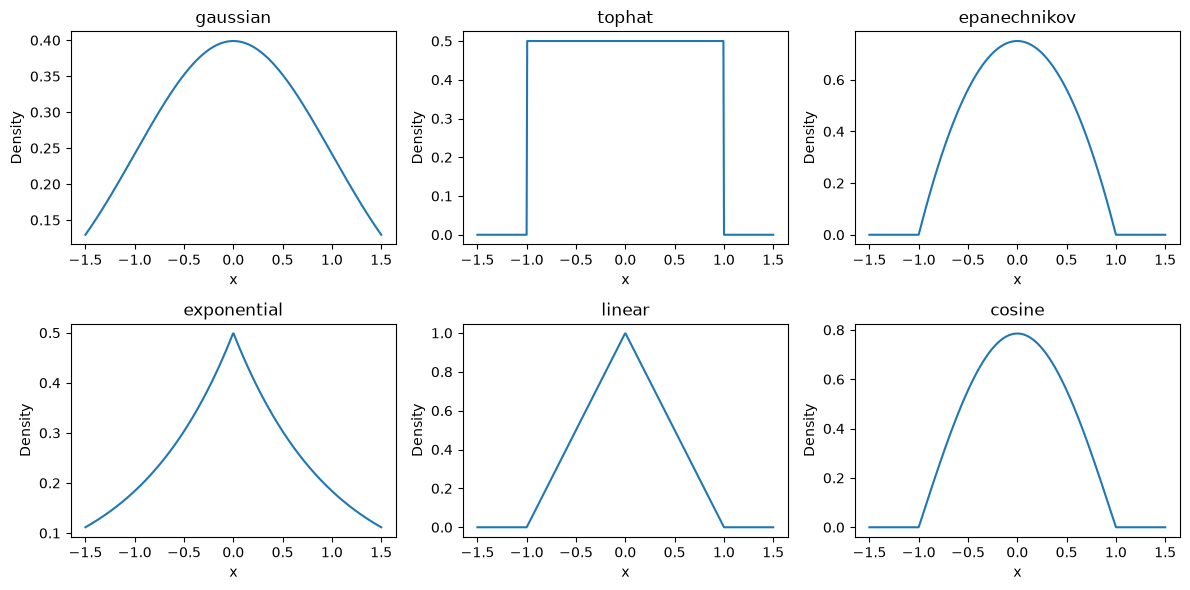

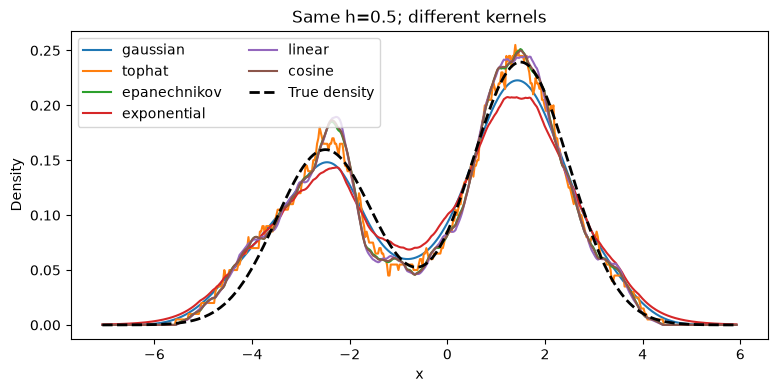

In [5]:
from sklearn.neighbors import KernelDensity
# Six kernels supported by sklearn.neighbors.KernelDensity.
kernel_names=['gaussian','tophat','epanechnikov','exponential','linear','cosine']
grid_kernel=np.linspace(-1.5,1.5,500)[:,None]
fig,axes=plt.subplots(2,3,figsize=(12,6))
for ax,name in zip(axes.flat,kernel_names):
    model=KernelDensity(kernel=name,bandwidth=1).fit(np.array([[0.0]]))
    ax.plot(grid_kernel[:,0],np.exp(model.score_samples(grid_kernel)))
    ax.set(title=name,xlabel='x',ylabel='Density')
fig.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(9,4));h=.5
for name in kernel_names:
    model=KernelDensity(kernel=name,bandwidth=h).fit(sample[:,None])
    ax.plot(xgrid,np.exp(model.score_samples(xgrid[:,None])),label=name)
ax.plot(xgrid,true_density,'k--',lw=2,label='True density')
ax.set(xlabel='x',ylabel='Density',title='Same h=0.5; different kernels');ax.legend(ncol=2);plt.show()

**Answer.** The six kernels have distinct profiles, in particular bounded or unbounded support. For a fixed h they produce different curves here, but the choice of h usually has a larger visual impact. Non-Gaussian kernels can show kinks depending on their shape.

**Q4 (bonus)**. The choice of $h$ has been widely studied in the literature. For example, `scikit-learn` offers two empirical rules for the *bandwidth* argument, Scott's rule and Silverman's rule, which set $h$ as a function of $n$ and $d$ (the data dimension).

Using a notion from the course, can you think of an optimality criterion to set $h$?

**Answer (bonus).** $h$ can be chosen by maximizing the **cross-validated predictive log-likelihood**: for each fold, fit the KDE on the other folds and sum the log-densities of the held-out observations. A small $h$ overfits and a large $h$ underfits. Evaluating the likelihood on the same points used for fitting would wrongly favor $h\to0$.

### Part 3: Kernel density estimation in 2D

Kernel density estimation extends to $d$ dimensions. The bandwidth can then be a symmetric positive-definite $d \times d$ matrix $\mathbf{H}$ (note: `scikit-learn` does not support this and only has a scalar bandwidth in $d$ dimensions).

**Q1**. Take the *Old Faithful* dataset from Lab 1 and estimate its density with a kernel estimator using `scikit-learn`. The choice of kernel and bandwidth is free.

Display the resulting density, for example as a *heatmap* with `plt.imshow` or as a *surface plot* (example [here](https://matplotlib.org/stable/gallery/mplot3d/surface3d.html)). Comment.

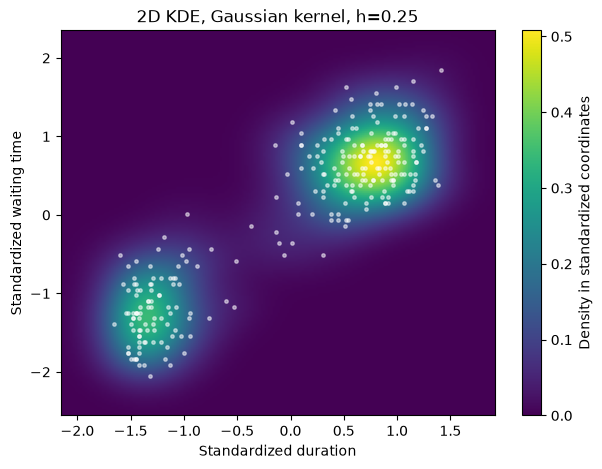

Old Faithful shape: (272, 2)


In [6]:
# Dataset provided with Lab 1, copied here so that Lab 2 runs offline.
from pathlib import Path
from sklearn.preprocessing import StandardScaler
geyser=np.load(Path('oldfaithful.npy'))
scaler=StandardScaler().fit(geyser);X_geyser=scaler.transform(geyser)
kde_2d=KernelDensity(kernel='gaussian',bandwidth=.25).fit(X_geyser)
xv,yv=np.meshgrid(np.linspace(X_geyser[:,0].min()-.5,X_geyser[:,0].max()+.5,180),np.linspace(X_geyser[:,1].min()-.5,X_geyser[:,1].max()+.5,180))
grid2=np.c_[xv.ravel(),yv.ravel()]
z=np.exp(kde_2d.score_samples(grid2)).reshape(xv.shape)
fig,ax=plt.subplots(figsize=(7,5))
im=ax.imshow(z,origin='lower',extent=[xv.min(),xv.max(),yv.min(),yv.max()],aspect='auto',cmap='viridis')
ax.scatter(*X_geyser.T,c='white',s=6,alpha=.5)
ax.set(xlabel='Standardized duration',ylabel='Standardized waiting time',title='2D KDE, Gaussian kernel, h=0.25')
fig.colorbar(im,ax=ax,label='Density in standardized coordinates');plt.show()
print('Old Faithful shape:',geyser.shape)

**Answer.** Standardization gives comparable weight to duration and waiting time, which are originally on different scales. The map highlights two high-density regions; a Gaussian kernel gives smooth contours without forcing exactly two components.

### Part 4: Kernel density estimation in 64D! A generative model

Once the density function has been estimated with kernels, we can sample from it, and therefore generate "fake data". We apply this to a simple image example: estimating the density gives us an image generator.


**Q1.** For this last question we use the *Digits* dataset, which contains about 1,800 grayscale 8×8 thumbnails that can be represented as vectors of size 64. The images are scanned digits from postal codes.

- Estimate the density with a kernel estimator using `scikit-learn`. The choice of kernel and bandwidth is free.
- Display 10 images from the dataset, then 10 images sampled from the estimated distribution, using the `.sample` method.
- Comment.

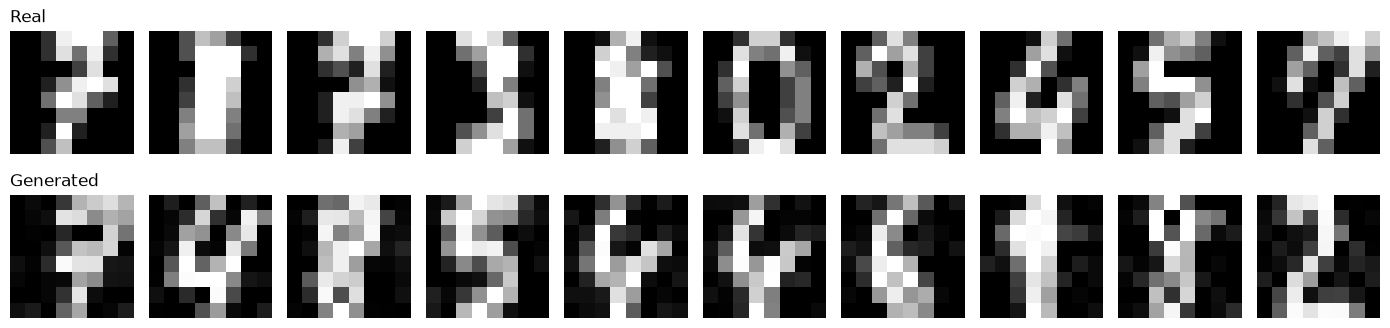

Shape: (1797, 64) ; range of samples before display: -3.889520808082887 18.51086473082255


In [7]:
from sklearn.datasets import load_digits
X_digits=load_digits().data.astype(float)
# Bandwidth in raw pixel intensities (0 to 16).
digits_kde=KernelDensity(kernel='gaussian',bandwidth=1.2).fit(X_digits)
new_digits=digits_kde.sample(10,random_state=42)
rng_display=np.random.default_rng(1)
real_indices=rng_display.choice(len(X_digits),10,replace=False)
fig,axes=plt.subplots(2,10,figsize=(14,3.6))
for i in range(10):
    axes[0,i].imshow(X_digits[real_indices[i]].reshape(8,8),cmap='gray',vmin=0,vmax=16)
    # Clipping is for display only; the Gaussian model can produce
    # values < 0 or > 16, outside the physical range of the pixels.
    axes[1,i].imshow(np.clip(new_digits[i],0,16).reshape(8,8),cmap='gray',vmin=0,vmax=16)
    for row in axes:row[i].axis('off')
axes[0,0].set_title('Real',loc='left');axes[1,0].set_title('Generated',loc='left')
fig.tight_layout();plt.show()
print('Shape:',X_digits.shape,'; range of samples before display:',new_digits.min(),new_digits.max())

**Answer.** A Gaussian KDE in 64 dimensions essentially generates a training image with Gaussian noise added to each pixel. The digits therefore usually look like existing examples, sometimes grainy; simulated intensities can leave [0,16] and are clipped **for the figure only**. In high dimension, estimating a density faithfully would require far more data.